# 전처리 설명 — 탱크 신호 정리

`Tank_Preprocess.py` 가 하는 일을 단계별로 눈으로 확인하는 노트북.

원시 PLC 신호를 진단 모델에 바로 넣으면 안 되는 이유가 있다. **exchanger 신호가
SV 문턱에서 초 단위로 들썩여서, 한 번의 냉각 동작이 수십 개 조각으로 쪼개져 보이기
때문**이다. 이걸 정리하지 않으면 "사이클 길이" 같은 지표가 전부 무의미해진다.

## 전처리 4단계

| 단계 | 하는 일 | 왜 |
|---|---|---|
| 1 | 온도 스케일 변환 | `TK_Temp_*` 는 0.1℃ 단위 |
| 2 | 센서 글리치 제거 | PV 가 0℃ / 327℃ 로 튀는 기록이 있음 |
| 3 | **exchanger 채터링 병합** | 핵심. 쪼개진 조각을 하나의 사이클로 |
| 4 | cool 동반 여부 표시 | 사이클마다 cool 이 같이 켜졌는지 |


## 0. 준비

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 160)

PARKKT = os.getcwd() if os.path.basename(os.getcwd()) == "parkkt" else os.path.join(os.getcwd(), "parkkt")
sys.path.insert(0, PARKKT)

import Tank_Preprocess as prep

TANK = "P1"
START, END = "2026-09-09 10:00:00", "now()"
print("대상 탱크:", TANK, "/", prep.TANKS[TANK])

대상 탱크: P1 / {'exch': '워킹 Tank 1 BACK Exchanger SOL', 'cool': '워킹 Tank 1 BACK Cooling SOL', 'pv': 'TK_Temp_PV_P1', 'lset': 'TK_Temp_L_Set_P1'}


In [2]:
sig = prep.load_signals(TANK, START, END)
for k, v in sig.items():
    print(f"{k:5s} {len(v):>9,}행   {v.index.min()} ~ {v.index.max()}")

exch     34,146행   2026-09-09 10:03:24.117296 ~ 2026-10-02 12:35:26.694115
cool     34,146행   2026-09-09 10:03:24.117296 ~ 2026-10-02 12:35:26.694115
pv    1,217,917행   2026-09-09 10:03:24.117296 ~ 2026-10-02 14:18:20.724721
lset      9,649행   2026-09-09 10:03:24.117296 ~ 2026-10-02 16:42:32.890152


## 1~2. 온도 스케일 변환 + 센서 글리치 제거

`TK_Temp_*` 는 0.1℃ 단위라 10 으로 나눈다 (`Scale_Max___TT_*=1000` 이라서).

그리고 PV 가 **물리적으로 불가능한 값으로 튀는 기록**이 있다. 2026-09-09 에 0℃ 와
327℃ 가 찍혔는데, 이걸 안 거르면 "일별 최저 PV" 가 0℃ 로 잡혀서 heat 진단이
오판정된다. 허용범위 밖은 버린다.

In [3]:
pv_raw, lset_raw = sig["pv"], sig["lset"]
pv, lset, n_glitch = prep.clean_temperature(pv_raw, lset_raw)

print(f"변환 전 PV 범위: {pv_raw.min():.0f} ~ {pv_raw.max():.0f} (0.1℃ 단위)")
print(f"변환 후 PV 범위: {(pv_raw/10).min():.1f} ~ {(pv_raw/10).max():.1f} ℃")
print(f"글리치 제거: {n_glitch}개  ->  {pv.min():.1f} ~ {pv.max():.1f} ℃")
print(f"L_Set: {lset.median():.1f} ℃")

변환 전 PV 범위: 0 ~ 3270 (0.1℃ 단위)
변환 후 PV 범위: 0.0 ~ 327.0 ℃
글리치 제거: 34개  ->  16.9 ~ 35.3 ℃
L_Set: 10.0 ℃


In [4]:
# 글리치가 일별 최저 PV 를 어떻게 망치는지
before = (pv_raw / 10).groupby((pv_raw.index.date)).min()
after = pv.groupby(pv.index.date).min()
cmp = pd.DataFrame({"제거 전": before, "제거 후": after})
cmp["차이"] = cmp["제거 후"] - cmp["제거 전"]
display(cmp[cmp["차이"].abs() > 0.01].round(1))

,제거 전,제거 후,차이
2026-09-09,0.0,17.1,17.1


## 3. exchanger 채터링 병합 — 핵심 단계

### 왜 필요한가

exchanger 는 온도가 SV 에 닿으면 켜지는데, 그 문턱에서 센서값이 229-230-231-230 식으로
들썩인다. 그래서 원시 신호는 0.5~3초짜리 ON/OFF 가 수십 번 반복되는 것처럼 보인다.

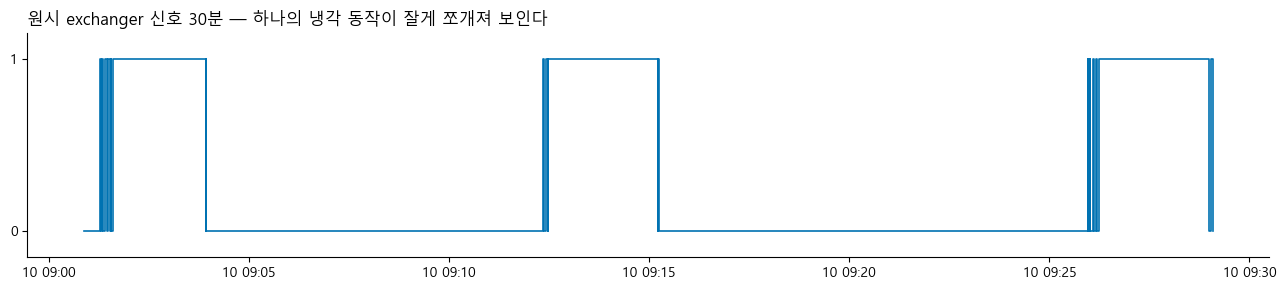

이 30분 안의 raw ON 구간 수: 17개


In [5]:
# 원시 신호를 30분만 확대해서 보기
t0 = pd.Timestamp("2026-09-10 09:00:00")
seg = sig["exch"].loc[t0:t0 + pd.Timedelta(minutes=30)]

fig, ax = plt.subplots(figsize=(13, 3))
ax.step(seg.index, seg.values, where="post", color="#0072B2", linewidth=1.2)
ax.set_ylim(-0.15, 1.15); ax.set_yticks([0, 1])
ax.set_title("원시 exchanger 신호 30분 — 하나의 냉각 동작이 잘게 쪼개져 보인다", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print(f"이 30분 안의 raw ON 구간 수: {len(prep.raw_segments(seg))}개")

### 어디서 끊을 것인가 — OFF 길이 분포

OFF 길이를 전부 모아보면 **두 덩어리로 완전히 갈린다.** 그 사이에 아무것도 없는
빈 구간이 있어서, 그 안의 값이면 임계를 어디로 잡든 결과가 같다.

짧은 쪽 최댓값 83.1초  /  긴 쪽 최솟값 115.0초
-> 그 사이 83.1 ~ 115.0초 구간에는 실측 데이터가 하나도 없다
   기본 임계 90초는 이 빈 구간 안에 있다


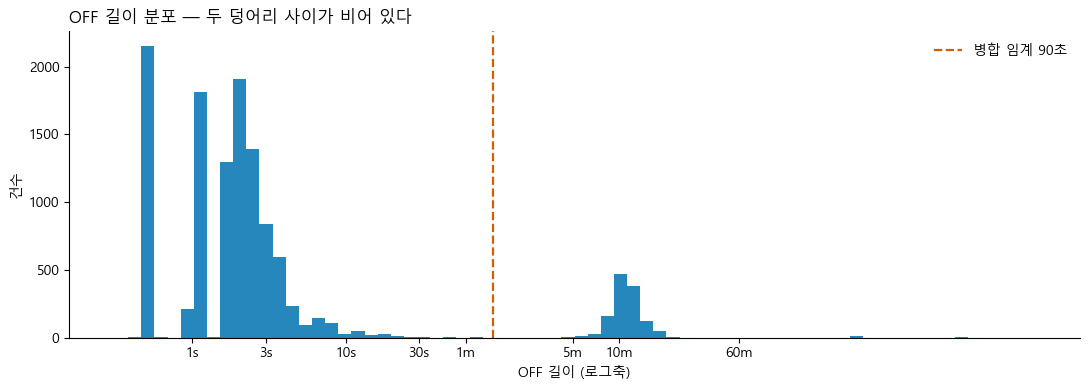

In [6]:
segs = prep.raw_segments(sig["exch"])
gaps = pd.Series([(segs[i+1][0] - segs[i][1]).total_seconds() for i in range(len(segs)-1)])

short_max = gaps[gaps < 100].max()
long_min = gaps[gaps > 100].min()
print(f"짧은 쪽 최댓값 {short_max:.1f}초  /  긴 쪽 최솟값 {long_min:.1f}초")
print(f"-> 그 사이 {short_max:.1f} ~ {long_min:.1f}초 구간에는 실측 데이터가 하나도 없다")
print(f"   기본 임계 {prep.MERGE_GAP_SEC}초는 이 빈 구간 안에 있다")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(gaps[gaps > 0]), bins=70, color="#0072B2", alpha=0.85)
ax.axvline(np.log10(prep.MERGE_GAP_SEC), color="#D55E00", linestyle="--", linewidth=1.6,
           label=f"병합 임계 {prep.MERGE_GAP_SEC}초")
ticks = [1, 3, 10, 30, 60, 300, 600, 3600]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([f"{t}s" if t < 60 else f"{t//60}m" for t in ticks])
ax.set_xlabel("OFF 길이 (로그축)"); ax.set_ylabel("건수")
ax.set_title("OFF 길이 분포 — 두 덩어리 사이가 비어 있다", loc="left")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

### 잘린 첫 사이클 버리기

데이터가 **exchanger 가 이미 켜져 있는 도중부터** 시작할 수 있다. 그 사이클은 언제
시작했는지 알 수 없어 길이를 믿을 수 없다 — 실측에서 5.8시간짜리 가짜 사이클이
만들어진 적이 있다.

그래서 ON 시작은 **데이터 안에서 0→1 전환이 실제로 보인 것만** 인정한다.
첫 샘플이 이미 1 이면 그 사이클은 자동으로 빠진다.

In [7]:
first_val = sig["exch"].iloc[0]
print(f"데이터 첫 샘플의 exchanger 값 = {first_val:.0f}")
print("-> 켜진 도중부터 시작. 첫 사이클은 버려진다" if first_val == 1
      else "-> 꺼진 상태에서 시작. 버릴 것 없음")

cycles = prep.merge_cycles(sig["exch"])
print(f"\nraw ON 구간 {len(segs):,}개  ->  병합 사이클 {len(cycles):,}개 "
      f"({len(segs)/len(cycles):.1f}:1 로 압축)")
display(cycles.head())

데이터 첫 샘플의 exchanger 값 = 1
-> 켜진 도중부터 시작. 첫 사이클은 버려진다



raw ON 구간 12,231개  ->  병합 사이클 1,254개 (9.8:1 로 압축)


,cycle_start,cycle_end,next_on,off_duration_sec,n_bridged,on_duration_sec
0,2026-09-09 16:10:41.225729,2026-09-09 16:12:58.123060,2026-09-09 16:23:18.999000,620.875940,4,136.897331
1,2026-09-09 16:23:18.999000,2026-09-09 16:26:04.471152,2026-09-09 16:35:48.470960,583.999808,6,165.472152
2,2026-09-09 16:35:48.470960,2026-09-09 16:39:08.507535,2026-09-09 16:47:37.041129,508.533594,3,200.036575
3,2026-09-09 16:47:37.041129,2026-09-09 16:51:07.264030,2026-09-09 16:58:13.976661,426.712631,6,210.222901
4,2026-09-09 16:58:13.976661,2026-09-09 17:01:27.898008,2026-09-09 17:11:01.129057,573.231049,4,193.921347


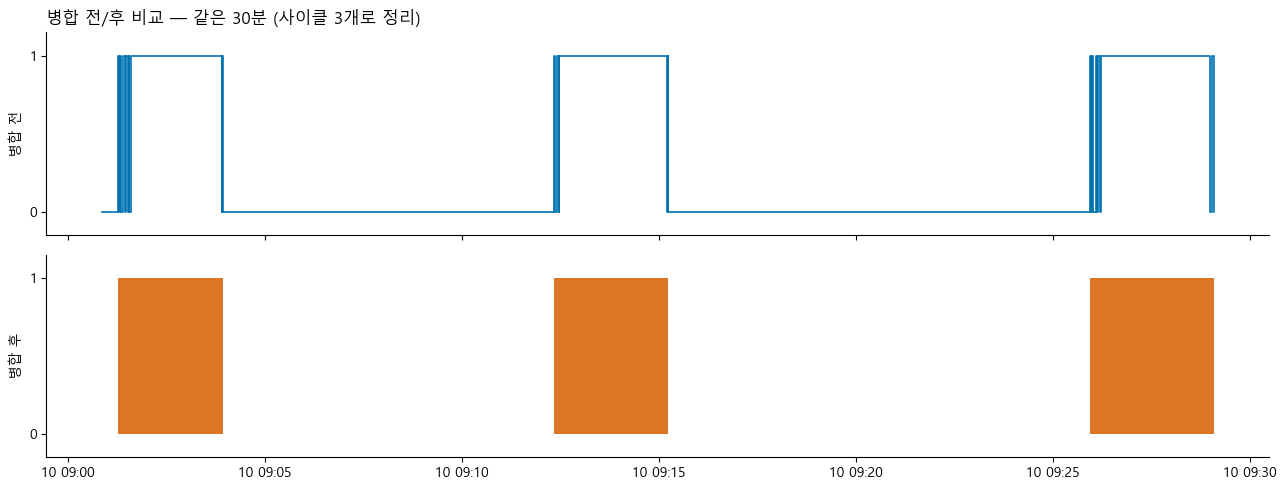

사이클별로 몇 개의 짧은 OFF 를 이어붙였는지(n_bridged):
               cycle_start  on_duration_sec  n_bridged
2026-09-10 09:01:15.814423       159.913443          6
2026-09-10 09:12:20.790710       173.909727          3
2026-09-10 09:25:57.320297       187.885769          5


In [8]:
# 병합 전/후 같은 구간 비교
t0 = pd.Timestamp("2026-09-10 09:00:00")
t1 = t0 + pd.Timedelta(minutes=30)
seg = sig["exch"].loc[t0:t1]
cyc_in = cycles[(cycles["cycle_start"] >= t0) & (cycles["cycle_start"] <= t1)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax1.step(seg.index, seg.values, where="post", color="#0072B2", linewidth=1.2)
ax1.set_ylim(-0.15, 1.15); ax1.set_yticks([0, 1]); ax1.set_ylabel("병합 전")
ax1.set_title(f"병합 전/후 비교 — 같은 30분 (사이클 {len(cyc_in)}개로 정리)", loc="left")
for _, r in cyc_in.iterrows():
    ax2.fill_between([r["cycle_start"], r["cycle_end"]], 0, 1,
                     color="#D55E00", alpha=0.85, linewidth=0)
ax2.set_ylim(-0.15, 1.15); ax2.set_yticks([0, 1]); ax2.set_ylabel("병합 후")
for a in (ax1, ax2):
    a.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print("사이클별로 몇 개의 짧은 OFF 를 이어붙였는지(n_bridged):")
print(cyc_in[["cycle_start", "on_duration_sec", "n_bridged"]].to_string(index=False))

## 4. cool 동반 여부

사이클 구간 동안 cool 이 한 번이라도 켜졌는지 표시한다. 진단 규칙 ②③ 에서
"exchanger 단독 문제인지 cool 까지 걸린 문제인지" 를 가르는 데 쓴다.

In [9]:
cycles = prep.flag_cool(cycles, sig["cool"])
print(f"cool 동반 사이클: {int(cycles['cool_overlap'].sum())}개 / {len(cycles)}개 "
      f"({100*cycles['cool_overlap'].mean():.1f}%)")
display(cycles.head())

cool 동반 사이클: 132개 / 1254개 (10.5%)


,cycle_start,cycle_end,next_on,off_duration_sec,n_bridged,on_duration_sec,cool_overlap
0,2026-09-09 16:10:41.225729,2026-09-09 16:12:58.123060,2026-09-09 16:23:18.999000,620.875940,4,136.897331,False
1,2026-09-09 16:23:18.999000,2026-09-09 16:26:04.471152,2026-09-09 16:35:48.470960,583.999808,6,165.472152,False
2,2026-09-09 16:35:48.470960,2026-09-09 16:39:08.507535,2026-09-09 16:47:37.041129,508.533594,3,200.036575,False
3,2026-09-09 16:47:37.041129,2026-09-09 16:51:07.264030,2026-09-09 16:58:13.976661,426.712631,6,210.222901,False
4,2026-09-09 16:58:13.976661,2026-09-09 17:01:27.898008,2026-09-09 17:11:01.129057,573.231049,4,193.921347,False


## 전체를 한 번에

위 1~4 단계는 `preprocess()` 한 줄로 끝난다.
**이미 전처리된 Series 를 갖고 있으면** `preprocess_signals(exch, cool, pv, lset)` 를 쓰면 된다.

In [10]:
data = prep.preprocess(TANK, START, END, verbose=True)
print()
print("반환 키:", list(data.keys()))
display(data["cycles"].head(3))

PV 글리치 제거 34개 (허용 5.0~60.0℃)
데이터가 exchanger 켜진 도중부터 시작 -> 첫 사이클 버림


raw ON 12,231개 -> 병합 사이클 1,254개 (cool 동반 132개)

반환 키: ['cycles', 'pv', 'lset', 'exch', 'cool']


,cycle_start,cycle_end,next_on,off_duration_sec,n_bridged,on_duration_sec,cool_overlap
0,2026-09-09 16:10:41.225729,2026-09-09 16:12:58.123060,2026-09-09 16:23:18.999000,620.875940,4,136.897331,False
1,2026-09-09 16:23:18.999000,2026-09-09 16:26:04.471152,2026-09-09 16:35:48.470960,583.999808,6,165.472152,False
2,2026-09-09 16:35:48.470960,2026-09-09 16:39:08.507535,2026-09-09 16:47:37.041129,508.533594,3,200.036575,False


## 전처리 결과 요약

| 항목 | 값 |
|---|---|
| 압축비 | raw ON 구간 → 사이클 |
| 버린 글리치 | PV 허용범위 밖 |
| 사이클당 평균 이어붙인 OFF | `n_bridged` 평균 |

In [11]:
cyc = data["cycles"]
print(f"사이클 수            {len(cyc):,}개")
print(f"사이클당 평균 n_bridged  {cyc['n_bridged'].mean():.1f}개")
print(f"ON 지속시간 중앙값      {cyc['on_duration_sec'].median():.0f}초")
print(f"ON 지속시간 범위        {cyc['on_duration_sec'].min():.0f} ~ {cyc['on_duration_sec'].max():.0f}초")
print(f"cool 동반 비율         {100*cyc['cool_overlap'].mean():.1f}%")

사이클 수            1,254개
사이클당 평균 n_bridged  8.8개
ON 지속시간 중앙값      173초
ON 지속시간 범위        16 ~ 3784초
cool 동반 비율         10.5%
